#### ============================================
###  1. Import Libraries
#### ============================================

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Preprocessing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import RandomizedSearchCV

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.ensemble import VotingClassifier

# Evaluation
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    ConfusionMatrixDisplay, 
    classification_report
)

import joblib

#### ============================================
###  2. Read a Data
#### ============================================

In [2]:
Data = pd.read_csv('/Users/mac/Desktop/Zain Projects/Task 3 Churn Dataset/data/raw/churn_data.csv')

#### ============================================
###  3. Check a Data
#### ============================================

In [3]:
Data.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [4]:
Data.shape[0]

7043

In [5]:
Data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [6]:
churn_counts = Data['Churn'].value_counts()

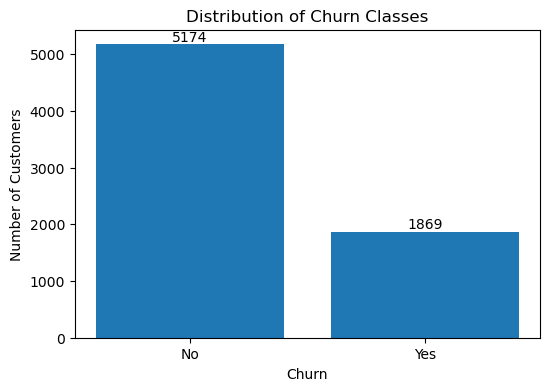

In [7]:
plt.figure(figsize=(6,4))
bars = plt.bar(churn_counts.index, churn_counts.values)

plt.title('Distribution of Churn Classes')
plt.xlabel('Churn')
plt.ylabel('Number of Customers')

# Display values on bars
for bar in bars:
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height(),
        f'{int(bar.get_height())}',
        ha='center',
        va='bottom'
    )

plt.show()

In [8]:
print(Data["Churn"].value_counts(normalize=True) * 100)

Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64


In [9]:
print(Data["TotalCharges"].dtype)

object


In [10]:
Data["TotalCharges"] = pd.to_numeric(
    Data["TotalCharges"],
    errors="coerce"
)

In [11]:
Data.isnull().sum()

customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

In [12]:
Data["TotalCharges"].fillna(
    Data["TotalCharges"].median(),
    inplace=True
)

/var/folders/qp/phjgxp894ns8_sk2pqy1hqjh0000gn/T/ipykernel_57457/3190975880.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  Data["TotalCharges"].fillna(


In [13]:
Data.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

#### ============================================
###  4. Split Features & Target
#### ============================================

In [14]:
X = Data.drop(columns=["customerID", "Churn"])

In [15]:
y = Data["Churn"]

In [16]:
print("Features Shape:", X.shape)
print("Target Shape:", y.shape)

Features Shape: (7043, 19)
Target Shape: (7043,)


#### ============================================
###  5. Encode Categorical Variables
#### ============================================

In [17]:
categorical_cols = X.select_dtypes(include=["object"]).columns

In [18]:
label_encoders = {}
categorical_cols = X.select_dtypes(include=['object']).columns

In [19]:
for col in categorical_cols:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col])
    label_encoders[col] = le

In [20]:
print("Categorical features encoded successfully!")

Categorical features encoded successfully!


In [21]:
y.head()

0     No
1     No
2    Yes
3     No
4    Yes
Name: Churn, dtype: object

In [22]:
target_encoder = LabelEncoder()
y = target_encoder.fit_transform(y)

In [23]:
y[:10]

array([0, 0, 1, 0, 1, 1, 0, 0, 1, 0])

In [24]:
print(label_encoders.keys())

dict_keys(['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod'])


#### ============================================
### 6. Train-Test Split
#### ============================================

In [25]:
# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [26]:
print("Training Features Shape:", X_train.shape)
print("Testing Features Shape :", X_test.shape)
print("Training Target Shape  :", y_train.shape)
print("Testing Target Shape   :", y_test.shape)

Training Features Shape: (5634, 19)
Testing Features Shape : (1409, 19)
Training Target Shape  : (5634,)
Testing Target Shape   : (1409,)


#### ============================================
### 7. Feature Scaling
#### ============================================

In [27]:
scaler = StandardScaler()

In [28]:
X_train_scaled = scaler.fit_transform(X_train)

In [29]:
X_test_scaled = scaler.transform(X_test)

#### ============================================
### 8. Verify Shapes
#### ============================================

In [30]:
print("Training Set:", X_train.shape)
print("Testing Set :", X_test.shape)

print("Scaled Training:", X_train_scaled.shape)
print("Scaled Testing :", X_test_scaled.shape)

Training Set: (5634, 19)
Testing Set : (1409, 19)
Scaled Training: (5634, 19)
Scaled Testing : (1409, 19)


#### ============================================
### 9. Build Piplines (SVM, Logistic Regression, Decision Tree, Random Forest, XGBOOST)
#### ============================================

#### 9.1 Logistic Regression

In [31]:
lr_pipeline = Pipeline([
    ("smote", SMOTE(random_state=42)),
    ("model", LogisticRegression(random_state=42))
])

lr_params = {
    "model__C": [0.01, 0.1, 1, 5, 10],
    "model__solver": ["lbfgs", "liblinear"],
    "model__penalty": ["l2"],
    "model__max_iter": [1000, 2000]
}

lr_grid = GridSearchCV(
    estimator=lr_pipeline,
    param_grid=lr_params,
    cv=5,
    scoring="f1",
    n_jobs=-1
)

lr_grid.fit(X_train_scaled, y_train)

GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('smote', SMOTE(random_state=42)),
                                       ('model',
                                        LogisticRegression(random_state=42))]),
             n_jobs=-1,
             param_grid={'model__C': [0.01, 0.1, 1, 5, 10],
                         'model__max_iter': [1000, 2000],
                         'model__penalty': ['l2'],
                         'model__solver': ['lbfgs', 'liblinear']},
             scoring='f1')

#### 9.2 SVM

In [32]:
svm_pipeline = Pipeline([
    ("smote", SMOTE(random_state=42)),
    ("model", SVC(probability=True, random_state=42))
])

svm_params = {
    "model__C": [0.1, 1, 2, 5, 10],
    "model__kernel": ["linear", "rbf"],
    "model__gamma": ["scale", "auto"],
    "model__class_weight": [None, "balanced"]
}

svm_grid = GridSearchCV(
    estimator=svm_pipeline,
    param_grid=svm_params,
    cv=5,
    scoring="f1",
    n_jobs=-1
)

svm_grid.fit(X_train_scaled, y_train)

GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('smote', SMOTE(random_state=42)),
                                       ('model',
                                        SVC(probability=True,
                                            random_state=42))]),
             n_jobs=-1,
             param_grid={'model__C': [0.1, 1, 2, 5, 10],
                         'model__class_weight': [None, 'balanced'],
                         'model__gamma': ['scale', 'auto'],
                         'model__kernel': ['linear', 'rbf']},
             scoring='f1')

#### 9.3 Decision Tree

In [33]:
dt_pipeline = Pipeline([
    ("smote", SMOTE(random_state=42)),
    ("model", DecisionTreeClassifier(random_state=42))
])

dt_params = {
    "model__criterion": ["gini", "entropy"],
    "model__max_depth": [5, 10, 15, 20],
    "model__min_samples_split": [2, 5, 10],
    "model__min_samples_leaf": [1, 2, 4],
    "model__splitter": ["best", "random"]
}

dt_grid = GridSearchCV(
    estimator=dt_pipeline,
    param_grid=dt_params,
    cv=5,
    scoring="f1",
    n_jobs=-1
)

dt_grid.fit(X_train, y_train)

GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('smote', SMOTE(random_state=42)),
                                       ('model',
                                        DecisionTreeClassifier(random_state=42))]),
             n_jobs=-1,
             param_grid={'model__criterion': ['gini', 'entropy'],
                         'model__max_depth': [5, 10, 15, 20],
                         'model__min_samples_leaf': [1, 2, 4],
                         'model__min_samples_split': [2, 5, 10],
                         'model__splitter': ['best', 'random']},
             scoring='f1')

#### 9.4 Random Forest Model

In [34]:
rf_pipeline = Pipeline([
    ("smote", SMOTE(random_state=42)),
    ("model", RandomForestClassifier(random_state=42))
])

rf_params = {
    "model__n_estimators":[100,200],
    "model__max_depth":[10,15],
    "model__min_samples_split":[2,5,10],
    "model__min_samples_leaf":[1,2,4],
    "model__max_features":["sqrt","log2"],
    "model__bootstrap":[True,False]
}

rf_grid = RandomizedSearchCV(
    estimator=rf_pipeline,
    param_distributions=rf_params,
    n_iter=20,
    cv=5,
    scoring="f1",
    random_state=42,
    n_jobs=-1
)

rf_grid.fit(X_train, y_train)

RandomizedSearchCV(cv=5,
                   estimator=Pipeline(steps=[('smote', SMOTE(random_state=42)),
                                             ('model',
                                              RandomForestClassifier(random_state=42))]),
                   n_iter=20, n_jobs=-1,
                   param_distributions={'model__bootstrap': [True, False],
                                        'model__max_depth': [10, 15],
                                        'model__max_features': ['sqrt', 'log2'],
                                        'model__min_samples_leaf': [1, 2, 4],
                                        'model__min_samples_split': [2, 5, 10],
                                        'model__n_estimators': [100, 200]},
                   random_state=42, scoring='f1')

#### 9.5 XGBoost Model

In [35]:
xgb_pipeline = Pipeline([
    ("smote", SMOTE(random_state=42)),
    ("model", XGBClassifier(
        objective="binary:logistic",
        eval_metric="logloss",
        random_state=42
    ))
])

xgb_params = {
    "model__n_estimators": [100, 200, 300],
    "model__learning_rate": [0.01, 0.05, 0.1, 0.2],
    "model__max_depth": [3, 5, 7, 9],
    "model__subsample": [0.6, 0.8, 1.0],
    "model__colsample_bytree": [0.6, 0.8, 1.0],
    "model__min_child_weight": [1,3,5],
    "model__gamma":[0,0.1,0.3]
}

xgb_grid = RandomizedSearchCV(
    estimator=xgb_pipeline,
    param_distributions=xgb_params,
    n_iter=20,
    cv=5,
    scoring="f1",
    random_state=42,
    n_jobs=-1
)

xgb_grid.fit(X_train, y_train)

RandomizedSearchCV(cv=5,
                   estimator=Pipeline(steps=[('smote', SMOTE(random_state=42)),
                                             ('model',
                                              XGBClassifier(base_score=None,
                                                            booster=None,
                                                            callbacks=None,
                                                            colsample_bylevel=None,
                                                            colsample_bynode=None,
                                                            colsample_bytree=None,
                                                            device=None,
                                                            early_stopping_rounds=None,
                                                            enable_categorical=False,
                                                            eval_metric='logloss',
                                                            feature_types=None,
                                                            feature_weights=None,
                                                            gamma=N...
                                                            n_jobs=None,
                                                            num_parallel_tree=None, ...))]),
                   n_iter=20, n_jobs=-1,
                   param_distributions={'model__colsample_bytree': [0.6, 0.8,
                                                                    1.0],
                                        'model__gamma': [0, 0.1, 0.3],
                                        'model__learning_rate': [0.01, 0.05,
                                                                 0.1, 0.2],
                                        'model__max_depth': [3, 5, 7, 9],
                                        'model__min_child_weight': [1, 3, 5],
                                        'model__n_estimators': [100, 200, 300],
                                        'model__subsample': [0.6, 0.8, 1.0]},
                   random_state=42, scoring='f1')

#### ============================================
### 10. Evaluate a Models
#### ============================================

In [36]:
def evaluate_model(model, X_test, y_test):

    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_prob)

    return accuracy, precision, recall, f1, roc_auc


results = []

# Logistic Regression
acc, pre, rec, f1, auc = evaluate_model(
    lr_grid.best_estimator_,
    X_test_scaled,
    y_test
)
results.append(["Logistic Regression", acc, pre, rec, f1, auc])

# SVM
acc, pre, rec, f1, auc = evaluate_model(
    svm_grid.best_estimator_,
    X_test_scaled,
    y_test
)
results.append(["SVM", acc, pre, rec, f1, auc])

# Decision Tree
acc, pre, rec, f1, auc = evaluate_model(
    dt_grid.best_estimator_,
    X_test,
    y_test
)
results.append(["Decision Tree", acc, pre, rec, f1, auc])

# Random Forest
acc, pre, rec, f1, auc = evaluate_model(
    rf_grid.best_estimator_,
    X_test,
    y_test
)
results.append(["Random Forest", acc, pre, rec, f1, auc])

# XGBoost
acc, pre, rec, f1, auc = evaluate_model(
    xgb_grid.best_estimator_,
    X_test,
    y_test
)
results.append(["XGBoost", acc, pre, rec, f1, auc])

In [37]:
print("Logistic Regression Best Parameters:")
print(lr_grid.best_params_)

print("\nSVM Best Parameters:")
print(svm_grid.best_params_)

print("\nDecision Tree Best Parameters:")
print(dt_grid.best_params_)

print("\nRandom Forest Best Parameters:")
print(rf_grid.best_params_)

print("\nXGBoost Best Parameters:")
print(xgb_grid.best_params_)

Logistic Regression Best Parameters:
{'model__C': 0.1, 'model__max_iter': 1000, 'model__penalty': 'l2', 'model__solver': 'liblinear'}

SVM Best Parameters:
{'model__C': 2, 'model__class_weight': None, 'model__gamma': 'scale', 'model__kernel': 'linear'}

Decision Tree Best Parameters:
{'model__criterion': 'gini', 'model__max_depth': 10, 'model__min_samples_leaf': 4, 'model__min_samples_split': 2, 'model__splitter': 'random'}

Random Forest Best Parameters:
{'model__n_estimators': 100, 'model__min_samples_split': 2, 'model__min_samples_leaf': 4, 'model__max_features': 'sqrt', 'model__max_depth': 10, 'model__bootstrap': True}

XGBoost Best Parameters:
{'model__subsample': 0.8, 'model__n_estimators': 300, 'model__min_child_weight': 1, 'model__max_depth': 5, 'model__learning_rate': 0.01, 'model__gamma': 0.1, 'model__colsample_bytree': 0.6}


#### ============================================
### 11. Comparing a Models
#### ============================================

In [38]:
results_df = pd.DataFrame(
    results,
    columns=[
        "Model",
        "Accuracy",
        "Precision",
        "Recall",
        "F1-Score",
        "ROC-AUC"
    ]
)

results_df = results_df.sort_values(
    by="ROC-AUC",
    ascending=False
).reset_index(drop=True)

results_df

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,SVM,0.730305,0.495050,0.802139,0.612245,0.840819
1,Logistic Regression,0.739532,0.506087,0.778075,0.613277,0.838022
2,XGBoost,0.762952,0.541322,0.700535,0.610723,0.837219
3,Random Forest,0.765082,0.546237,0.679144,0.605483,0.833220
4,Decision Tree,0.743790,0.513347,0.668449,0.580720,0.779162


#### ============================================
### 12. Confusion Matrix & Classification Report
#### ============================================

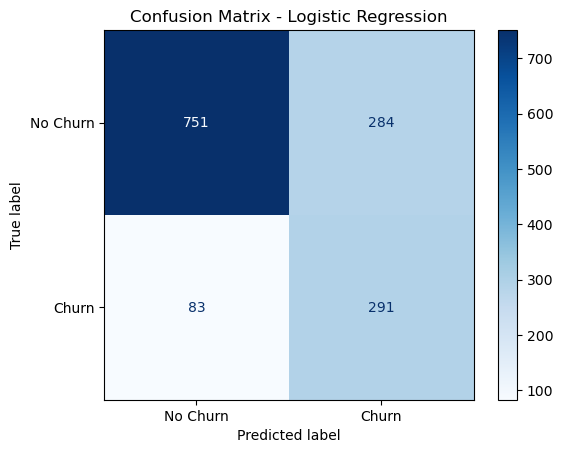

              precision    recall  f1-score   support

    No Churn       0.90      0.73      0.80      1035
       Churn       0.51      0.78      0.61       374

    accuracy                           0.74      1409
   macro avg       0.70      0.75      0.71      1409
weighted avg       0.80      0.74      0.75      1409



In [39]:
# Select the best model
best_model = lr_grid.best_estimator_

# Predictions
y_pred = best_model.predict(X_test_scaled)

# Confusion Matrix
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    display_labels=["No Churn", "Churn"],
    cmap="Blues",
    values_format="d"
)

plt.title("Confusion Matrix - Logistic Regression")
plt.show()

# Classification Report
print(classification_report(
    y_test,
    y_pred,
    target_names=["No Churn", "Churn"]
))

#### ============================================
### 13. Ensemble Model (Soft Voting)
#### ============================================

In [40]:
ensemble_model = VotingClassifier(
    estimators=[
        ("lr", lr_grid.best_estimator_),
        ("svm", svm_grid.best_estimator_),
        ("xgb", xgb_grid.best_estimator_)
    ],
    voting="soft",
    n_jobs=-1
)

ensemble_model.fit(X_train_scaled, y_train)

VotingClassifier(estimators=[('lr',
                              Pipeline(steps=[('smote', SMOTE(random_state=42)),
                                              ('model',
                                               LogisticRegression(C=0.1,
                                                                  max_iter=1000,
                                                                  random_state=42,
                                                                  solver='liblinear'))])),
                             ('svm',
                              Pipeline(steps=[('smote', SMOTE(random_state=42)),
                                              ('model',
                                               SVC(C=2, kernel='linear',
                                                   probability=True,
                                                   random_state=42))])),
                             ('xgb',
                              Pipeline(steps=[('smote', SMOTE(random_state=...
                                                             grow_policy=None,
                                                             importance_type=None,
                                                             interaction_constraints=None,
                                                             learning_rate=0.01,
                                                             max_bin=None,
                                                             max_cat_threshold=None,
                                                             max_cat_to_onehot=None,
                                                             max_delta_step=None,
                                                             max_depth=5,
                                                             max_leaves=None,
                                                             min_child_weight=1,
                                                             missing=nan,
                                                             monotone_constraints=None,
                                                             multi_strategy=None,
                                                             n_estimators=300,
                                                             n_jobs=None,
                                                             num_parallel_tree=None, ...))]))],
                 n_jobs=-1, voting='soft')

#### ============================================
### 14. Evaluate Ensemble
#### ============================================

In [41]:
acc, pre, rec, f1, auc = evaluate_model(
    ensemble_model,
    X_test_scaled,
    y_test
)

print("Ensemble Model Results")
print(f"Accuracy : {acc:.4f}")
print(f"Precision: {pre:.4f}")
print(f"Recall   : {rec:.4f}")
print(f"F1-Score : {f1:.4f}")
print(f"ROC-AUC  : {auc:.4f}")

Ensemble Model Results
Accuracy : 0.7516
Precision: 0.5214
Recall   : 0.7807
F1-Score : 0.6253
ROC-AUC  : 0.8438


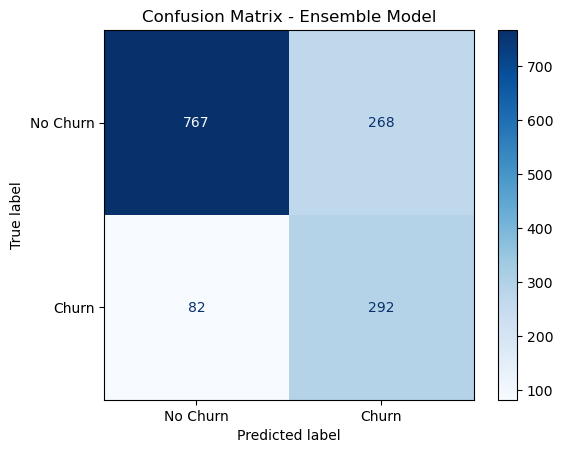

              precision    recall  f1-score   support

    No Churn       0.90      0.74      0.81      1035
       Churn       0.52      0.78      0.63       374

    accuracy                           0.75      1409
   macro avg       0.71      0.76      0.72      1409
weighted avg       0.80      0.75      0.76      1409



In [42]:
y_pred = ensemble_model.predict(X_test_scaled)

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    display_labels=["No Churn","Churn"],
    cmap="Blues"
)

plt.title("Confusion Matrix - Ensemble Model")
plt.show()

print(classification_report(
    y_test,
    y_pred,
    target_names=["No Churn","Churn"]
))

In [43]:
results_df.loc[len(results_df)] = [
    "Ensemble",
    acc,
    pre,
    rec,
    f1,
    auc
]

results_df = (
    results_df
    .sort_values(by=["F1-Score","ROC-AUC"], ascending=False)
    .reset_index(drop=True)
)

results_df.round(4)

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Ensemble,0.7516,0.5214,0.7807,0.6253,0.8438
1,Logistic Regression,0.7395,0.5061,0.7781,0.6133,0.8380
2,SVM,0.7303,0.4950,0.8021,0.6122,0.8408
3,XGBoost,0.7630,0.5413,0.7005,0.6107,0.8372
4,Random Forest,0.7651,0.5462,0.6791,0.6055,0.8332
5,Decision Tree,0.7438,0.5133,0.6684,0.5807,0.7792


#### ============================================
### 15. Ensemble Model (Soft Voting)
#### ============================================

In [44]:
joblib.dump(ensemble_model, "best_model.pkl")
joblib.dump(scaler, "scaler.pkl")
joblib.dump(label_encoders, "label_encoders.pkl")
joblib.dump(target_encoder, "target_encoder.pkl")

['target_encoder.pkl']